In [1]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS

from tqdm import tqdm

In [3]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [4]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [5]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [6]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [7]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


In [54]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2


In [55]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [56]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [57]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [58]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [59]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [60]:
k_map = 10
n_d0_grid_map = 400

In [61]:
# Population dataframes for cloning / per-population workflows
s3m_mba = s3m
s3m_neo = neo
s3m_tno = tno
s3m_tjn = trojan  

In [62]:
import gc
import numpy as np
from scipy.spatial import cKDTree
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2
def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None, randomize_phase=True):
    """
    Clone each orbit clone_factor times.

    If randomize_phase=True:
        assign a random mean anomaly at obstime_str (original behavior)

    If randomize_phase=False:
        preserve original orbital phase (t_p unchanged)
    """

    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    # ALWAYS use 'a' from dataset
    a_AU = df["a"].to_numpy(dtype=np.float32)
    e = df["e"].to_numpy(dtype=np.float32)
    inc = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp = df["t_p"].to_numpy(dtype=np.float64)

    # repeat elements
    a_rep   = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep   = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)
    tp_rep   = np.repeat(tp, clone_factor).astype(np.float64)

    if randomize_phase:
        # mean motion
        a_km = a_rep.astype(np.float64) * AU_km
        n_rad_s = np.sqrt(mu_sun / (a_km**3))
        n_rad_day = n_rad_s * 86400.0

        # random mean anomaly
        M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep)).astype(np.float64)

        # adjust tp so M(obstime)=M_rand
        tp_out = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)
    else:
        # KEEP ORIGINAL PHASE
        tp_out = tp_rep.astype(np.float32)

    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_out

In [63]:
# Convert orbital elements -> vlam, vbeta using existing pipeline
# but with a configurable sky center in ecliptic lon/lat

def elements_to_vlam_vbeta(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import (
        SkyCoord, GCRS, get_sun, GeocentricTrueEcliptic
    )

    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and RA/Dec rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of the sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg

    m = sep <= max_sep_deg
    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta)
    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)

    return vlam, vbeta

In [64]:
# 06/04 random phase flag added
# Clone configuration (less memory intensive)

clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,   # first test: no MBA cloning yet
        "randomize_phase": True,
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "randomize_phase": True,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "randomize_phase": True,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "randomize_phase": False,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

rng = np.random.default_rng(42)
overlay_max = 100_000

In [65]:
# Build cloned rate-space populations one at a time
# Keeps only small overlay samples + final maps

clone_overlay = {}
clone_density_maps = {}
clone_density_maps_downweighted = {}

for pop_name, info in clone_sources.items():
    f = info["clone_factor"]
    df = info["df"]

    print(f"\nCloning {pop_name} with factor {f}...")

    randomize_phase = info.get("randomize_phase", True)
    
    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df,
        clone_factor=f,
        obstime_str=obstime_str,
        rng=rng,
        randomize_phase=randomize_phase,
    )
    
    print("  cloned orbit count:", len(a_rep))

    vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
        obstime_str=obstime_str,
        scorer=info["scorer"],
        max_sep_deg=max_sep_deg,
        chunk=100_000,
        show_progress=True,
    )
    print(f"  final cloned visible points: {len(vlam_clone)}")

    # raw element arrays no longer needed
    del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
    gc.collect()

    # keep only a small random subset for plotting overlays
    n_overlay = min(overlay_max, len(vlam_clone))
    idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
    clone_overlay[pop_name] = {
        "vlam": vlam_clone[idx_overlay].copy(),
        "vbeta": vbeta_clone[idx_overlay].copy(),
        "scatter_size": info["scatter_size"],
        "scatter_alpha": info["scatter_alpha"],
    }

    pts_clone = np.column_stack([vlam_clone, vbeta_clone])
    tree_clone = cKDTree(pts_clone)

    density_clone_flat = evaluate_density_map_full_posterior_2d(
        tree_clone,
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_clone_map = density_clone_flat.reshape(X0.shape)
    density_downweighted_map = density_clone_map / f

    clone_density_maps[pop_name] = density_clone_map
    clone_density_maps_downweighted[pop_name] = density_downweighted_map

    print(f"{pop_name} done.")
    print("  raw cloned max density   :", np.nanmax(density_clone_map))
    print("  downweighted max density :", np.nanmax(density_downweighted_map))

    # cleanup large arrays before next population
    del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
    gc.collect()


Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.00it/s]


  final cloned visible points: 1418518


Evaluating density map: 100%|██████████| 25921/25921 [07:46<00:00, 55.60it/s]


MBA done.
  raw cloned max density   : 393660850.11085695
  downweighted max density : 393660850.11085695

Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 4990382200.988374
  downweighted max density : 499038220.0988374

Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:00<00:00, 19.35it/s]


  final cloned visible points: 236050


Evaluating density map: 100%|██████████| 25921/25921 [07:55<00:00, 54.46it/s]


Trojans done.
  raw cloned max density   : 1040564183.8871094
  downweighted max density : 104056418.38871095


In [67]:
def build_cloned_maps_for_center(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] Cloning {pop_name} with factor {f}...")

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            df, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print(f"  final cloned visible points: {len(vlam_clone)}")

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)

        clone_overlay[pop_name] = {
            "vlam": vlam_clone[idx_overlay].copy(),
            "vbeta": vbeta_clone[idx_overlay].copy(),
            "scatter_size": info["scatter_size"],
            "scatter_alpha": info["scatter_alpha"],
        }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        tree_clone = cKDTree(pts_clone)

        density_clone_flat = evaluate_density_map_full_posterior_2d(
            tree_clone,
            grid_points,
            k=k_map,
            n_d0_grid=n_d0_grid_map,
            show_progress=True,
        )

        density_clone_map = density_clone_flat.reshape(X0.shape)
        density_downweighted_map = density_clone_map / f

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

In [69]:
def elements_to_eclipticstrip_quantities_chunk(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    beta_max_deg=3.0,
    rate_chunk=100_000,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import SkyCoord, GCRS, GeocentricTrueEcliptic

    t_obs = Time(obstime_str, scale="tdb")

    #  heliocentric ecliptic state from orbital elements
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=rate_chunk,
        show_progress=False,
    )

    #  ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    del r_obj_ecl, v_obj_ecl

    #  observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # 4) topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    del r_obj_helio, v_obj_helio

    #  Cartesian -> RA, Dec and rates
    x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & np.isfinite(r2) &
        (rho2 > 0) & (r2 > 0)
    )

    ra_deg       = (np.rad2deg(ra[good]) % 360.0).astype(np.float32)
    dec_deg      = np.rad2deg(dec[good]).astype(np.float32)
    dra_deg_day  = (np.rad2deg(dra[good])  * 86400.0).astype(np.float32)
    ddec_deg_day = (np.rad2deg(ddec[good]) * 86400.0).astype(np.float32)

    del r_rel, v_rel, x, y, z, vx, vy, vz, rho2, r2, rho, ra, dec, dra, ddec, good

    #  convert to ecliptic longitude/latitude
    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )
    ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg  = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    #  convert RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam  = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    lam_deg  = lam_deg[finite]
    beta_deg = beta_deg[finite]
    vlam     = vlam[finite]
    vbeta    = vbeta[finite]

    #  ecliptic-strip cut
    m_beta = np.abs(beta_deg) < beta_max_deg

    return lam_deg[m_beta], beta_deg[m_beta], vlam[m_beta], vbeta[m_beta]

In [70]:
def build_eclipticstrip_for_population_chunked(
    df,
    scorer,
    clone_factor,
    obstime_str,
    beta_max_deg=3.0,
    object_chunk=50_000,
    rate_chunk=100_000,
    rng=None,
    randomize_phase=True,
    verbose=True,
):
    import gc

    if rng is None:
        rng = np.random.default_rng(42)

    n_obj = len(df)

    lam_list = []
    beta_list = []
    vlam_list = []
    vbeta_list = []

    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0 + object_chunk, n_obj)

        if verbose:
            print(f"Objects {i0:,} to {i1:,} of {n_obj:,}")

        df_chunk = df.iloc[i0:i1]

        # reuse main code function instead of rebuilding repeat/randomize logic here
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_use = clone_population_random_mean_anomaly(
            df_chunk,
            clone_factor=clone_factor,
            obstime_str=obstime_str,
            rng=rng,
            randomize_phase=randomize_phase,
        )

        lam_deg, beta_deg, vlam, vbeta = elements_to_eclipticstrip_quantities_chunk(
            a_AU=a_rep,
            e=e_rep,
            inc=inc_rep,
            raan=raan_rep,
            argp=argp_rep,
            tp_mjd=tp_use,
            obstime_str=obstime_str,
            scorer=scorer,
            beta_max_deg=beta_max_deg,
            rate_chunk=rate_chunk,
        )

        lam_list.append(lam_deg)
        beta_list.append(beta_deg)
        vlam_list.append(vlam)
        vbeta_list.append(vbeta)

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_use
        del lam_deg, beta_deg, vlam, vbeta
        gc.collect()

    lam_all_out   = np.concatenate(lam_list).astype(np.float32) if lam_list else np.array([], dtype=np.float32)
    beta_all_out  = np.concatenate(beta_list).astype(np.float32) if beta_list else np.array([], dtype=np.float32)
    vlam_all_out  = np.concatenate(vlam_list).astype(np.float32) if vlam_list else np.array([], dtype=np.float32)
    vbeta_all_out = np.concatenate(vbeta_list).astype(np.float32) if vbeta_list else np.array([], dtype=np.float32)

    return {
        "lam_deg": lam_all_out,
        "beta_deg": beta_all_out,
        "vlam": vlam_all_out,
        "vbeta": vbeta_all_out,
    }

In [71]:

fig5_mba_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=clone_sources["MBA"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(501),
    randomize_phase=clone_sources["MBA"].get("randomize_phase", True),
    verbose=True,
)

fig5_neo_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=clone_sources["NEO"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(502),
    randomize_phase=clone_sources["NEO"].get("randomize_phase", True),
    verbose=True,
)

fig5_tno_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["TNO"]["df"],
    scorer=clone_sources["TNO"]["scorer"],
    clone_factor=clone_sources["TNO"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(503),
    randomize_phase=clone_sources["TNO"].get("randomize_phase", True),
    verbose=True,
)

# no phase randomization
fig5_trojan_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["Trojans"]["df"],
    scorer=clone_sources["Trojans"]["scorer"],
    clone_factor=1,  # make sure no cloning
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(504),
    randomize_phase=False,  
    verbose=True,
)

print("MBA selected:", len(fig5_mba_ecliptic["lam_deg"]))
print("NEO selected:", len(fig5_neo_ecliptic["lam_deg"]))
print("TNO selected:", len(fig5_tno_ecliptic["lam_deg"]))
print("Trojans selected:", len(fig5_trojan_ecliptic["lam_deg"]))

Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,361
Objects 460,000 to 480,000 of 13,883,361
Objects 480,000 to 500,000 of 

In [80]:
def plot_eclipticstrip_populations(
    population_data,
    populations=None,
    beta_max_deg=3.0,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points=None,
    seed=123,
    title="Ecliptic-strip plot",
):
    """
    General ecliptic-strip plotter for any subset of populations.

    Parameters
    ----------
    population_data : dict
        Mapping like:
        {
            "MBA": fig5_mba_ecliptic,
            "NEO": fig5_neo_ecliptic,
            "TNO": fig5_tno_ecliptic,
            "Trojans": fig5_trojan_ecliptic,
        }

    populations : list[str] or None
        Which populations to plot. If None, plot all keys in population_data.

    max_points : dict or None
        Optional per-population sampling limits, e.g.
        {"MBA": 150_000, "NEO": 50_000, "TNO": 50_000, "Trojans": 80_000}
    """
    rng = np.random.default_rng(seed)

    if populations is None:
        populations = list(population_data.keys())

    if max_points is None:
        max_points = {pop: 100_000 for pop in populations}

    
    style_map = {
    "MBA": {"alpha": 0.22, "s": 1, "color": "orange"},
    "NEO": {"alpha": 0.08, "s": 1, "color": "blue"},
    "TNO": {"alpha": 0.18, "s": 1, "color": "green"},
    "Trojans": {"alpha": 0.18, "s": 1, "color": "purple"},
    }

    prepared = {}

    for pop in populations:
        data = population_data[pop]

        lam = np.mod(data["lam_deg"], 360.0)
        beta = data["beta_deg"]
        vlam = data["vlam"]
        vbeta = data["vbeta"]

        lam_lo, lam_hi = lam_window
        if lam_lo <= lam_hi:
            m = (lam >= lam_lo) & (lam <= lam_hi)
        else:
            m = (lam >= lam_lo) | (lam <= lam_hi)

        lam = lam[m]
        beta = beta[m]
        vlam = vlam[m]
        vbeta = vbeta[m]

        nmax = max_points.get(pop, len(lam))
        if len(lam) > nmax:
            idx = rng.choice(len(lam), size=nmax, replace=False)
            lam = lam[idx]
            beta = beta[idx]
            vlam = vlam[idx]
            vbeta = vbeta[idx]

        prepared[pop] = {
            "lam": lam,
            "beta": beta,
            "vlam": vlam,
            "vbeta": vbeta,
        }

        print(f"{pop} in window: {len(lam)}")

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(9, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    for pop in populations:
        st = style_map.get(pop, {"alpha": 0.18, "s": 1})
        d = prepared[pop]

        ax1.scatter(d["lam"], d["beta"], s=st["s"], alpha=st["alpha"], color=st["color"], label=pop)
        ax2.scatter(d["lam"], d["vlam"], s=st["s"], alpha=st["alpha"], color=st["color"])
        ax3.scatter(d["lam"], d["vbeta"], s=st["s"], alpha=st["alpha"], color=st["color"])

    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*vlam_ylim)

    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*vbeta_ylim)

    # full 0–360 display
    if lam_window == (0.0, 360.0) or lam_window == (0, 360):
        ax3.set_xlim(360, 0)
    else:
        lam_lo, lam_hi = lam_window
        ax3.set_xlim(lam_hi, lam_lo)

    fig.suptitle(title + f"\nwith |beta| < {beta_max_deg}°")
    plt.show()

In [81]:
ecliptic_population_data = {
    "MBA": fig5_mba_ecliptic,
    "NEO": fig5_neo_ecliptic,
    "TNO": fig5_tno_ecliptic,
    "Trojans": fig5_trojan_ecliptic,
}

MBA in window: 150000
NEO in window: 50000


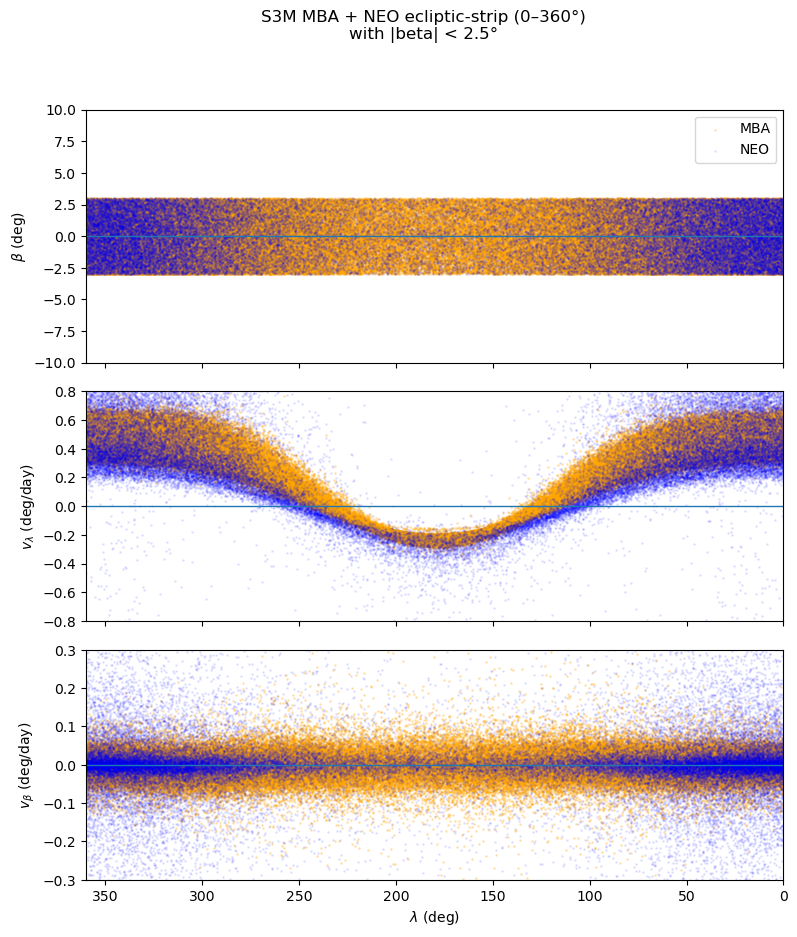

In [83]:
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["MBA", "NEO"],
    beta_max_deg=2.5,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points={"MBA": 150_000, "NEO": 50_000},
    seed=503,
    title="S3M MBA + NEO ecliptic-strip (0–360°)",
)

NEO in window: 50000
MBA in window: 150000


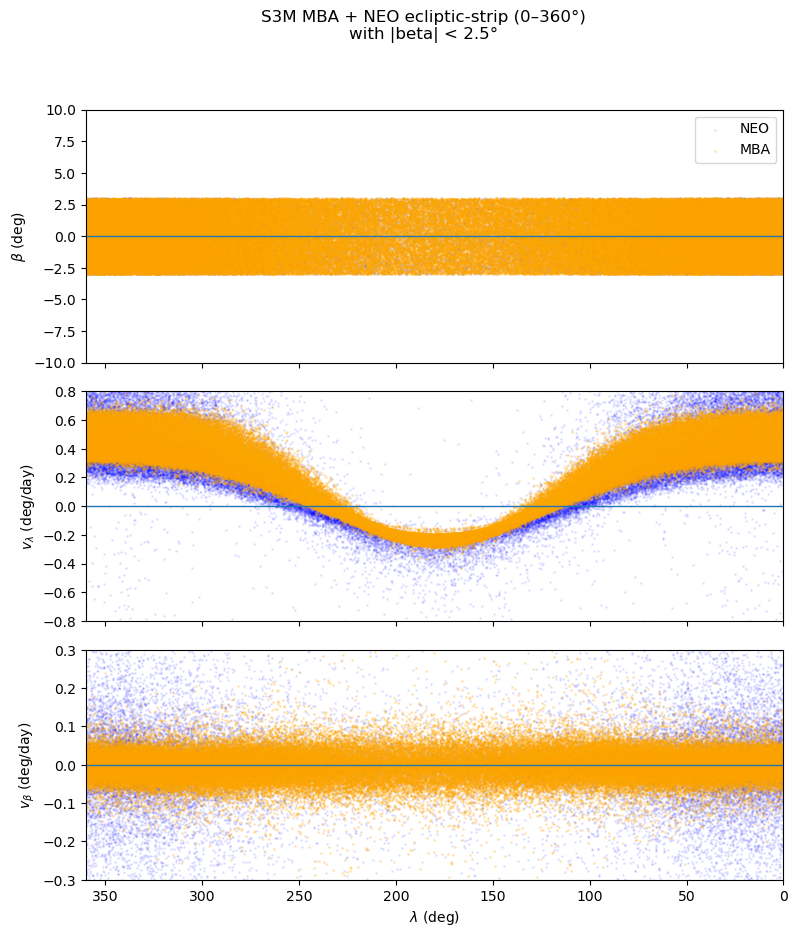

In [84]:
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["NEO", "MBA"],
    beta_max_deg=2.5,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points={"MBA": 150_000, "NEO": 50_000},
    seed=503,
    title="S3M MBA + NEO ecliptic-strip (0–360°)",
)

Trojans in window: 37227


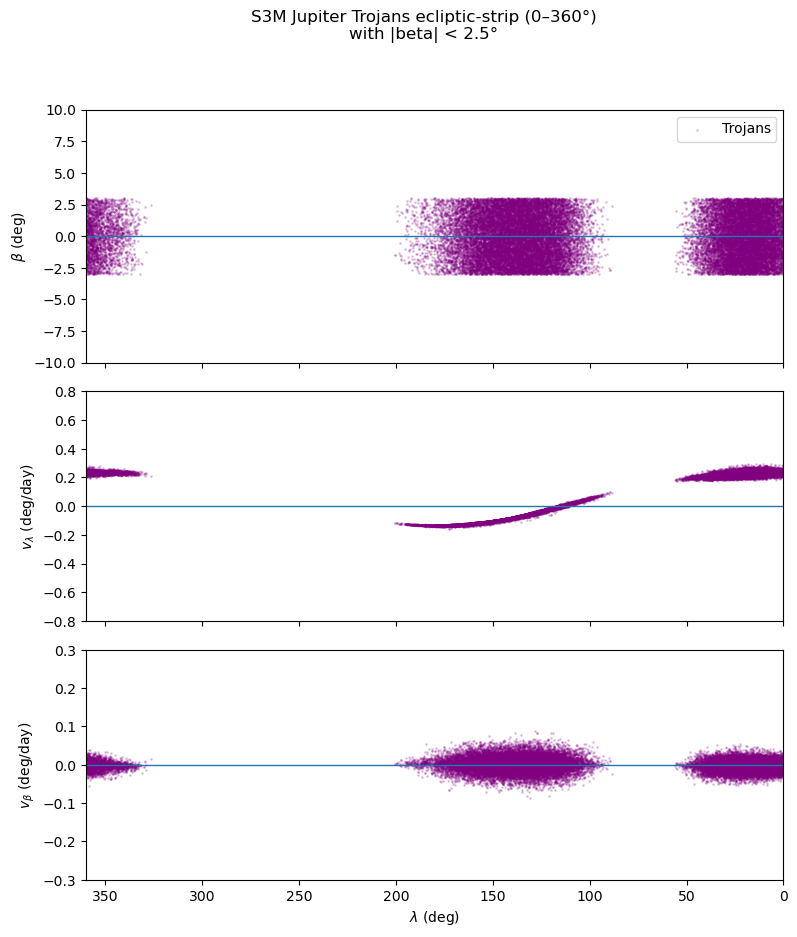

In [88]:
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["Trojans"],
    beta_max_deg=2.5,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points={"Trojans": 100_000},
    title="S3M Jupiter Trojans ecliptic-strip (0–360°)",
)

TNO in window: 100000


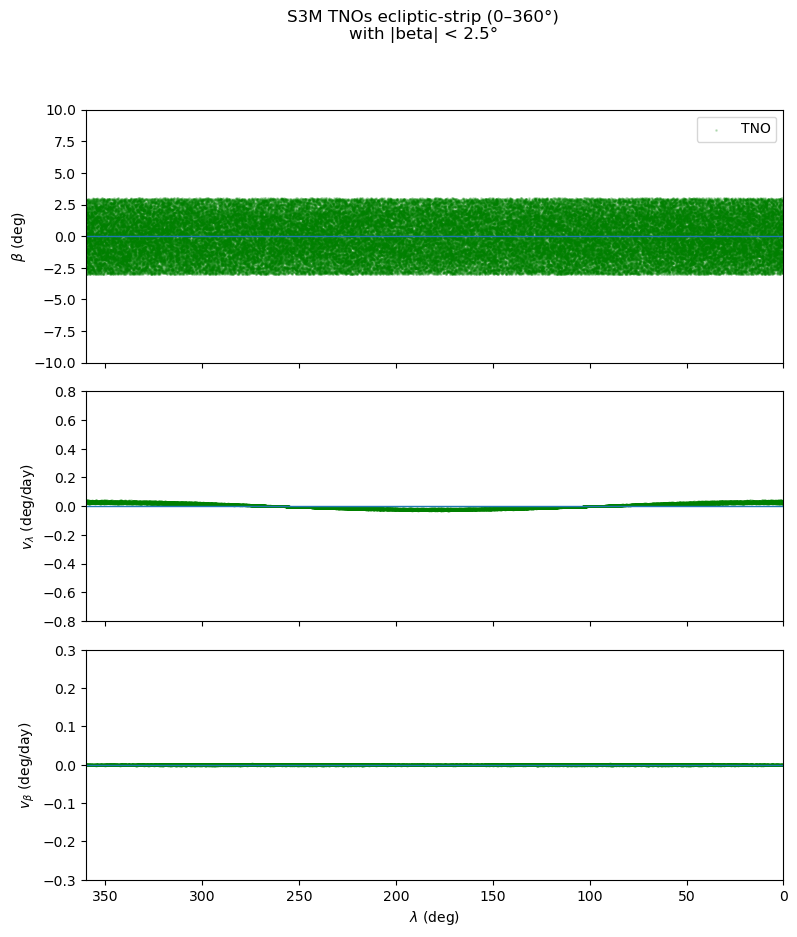

In [90]:
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["TNO"],
    beta_max_deg=2.5,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points={"TNO": 100_000},
    seed=503,
    title="S3M TNOs ecliptic-strip (0–360°)",
)

In [91]:
def build_eclipticstrip_for_population_with_xy_chunked(
    df,
    scorer,
    clone_factor,
    obstime_str,
    beta_max_deg=3.0,
    object_chunk=50_000,
    rate_chunk=100_000,
    rng=None,
    randomize_phase=True,
    verbose=True,
):
    import gc

    if rng is None:
        rng = np.random.default_rng(42)

    n_obj = len(df)

    lam_list = []
    beta_list = []
    vlam_list = []
    vbeta_list = []
    xh_list = []
    yh_list = []

    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0 + object_chunk, n_obj)

        if verbose:
            print(f"Objects {i0:,} to {i1:,} of {n_obj:,}")

        df_chunk = df.iloc[i0:i1]

        # 
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_use = clone_population_random_mean_anomaly(
            df_chunk,
            clone_factor=clone_factor,
            obstime_str=obstime_str,
            rng=rng,
            randomize_phase=randomize_phase,
        )

        lam_deg, beta_deg, vlam, vbeta, xh, yh = elements_to_eclipticstrip_quantities_with_xy_chunk(
            a_AU=a_rep,
            e=e_rep,
            inc=inc_rep,
            raan=raan_rep,
            argp=argp_rep,
            tp_mjd=tp_use,
            obstime_str=obstime_str,
            scorer=scorer,
            beta_max_deg=beta_max_deg,
            rate_chunk=rate_chunk,
        )

        lam_list.append(lam_deg)
        beta_list.append(beta_deg)
        vlam_list.append(vlam)
        vbeta_list.append(vbeta)
        xh_list.append(xh)
        yh_list.append(yh)

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_use
        del lam_deg, beta_deg, vlam, vbeta, xh, yh
        gc.collect()

    return {
        "lam_deg": np.concatenate(lam_list).astype(np.float32) if lam_list else np.array([], dtype=np.float32),
        "beta_deg": np.concatenate(beta_list).astype(np.float32) if beta_list else np.array([], dtype=np.float32),
        "vlam": np.concatenate(vlam_list).astype(np.float32) if vlam_list else np.array([], dtype=np.float32),
        "vbeta": np.concatenate(vbeta_list).astype(np.float32) if vbeta_list else np.array([], dtype=np.float32),
        "x_helio_ecl": np.concatenate(xh_list).astype(np.float32) if xh_list else np.array([], dtype=np.float32),
        "y_helio_ecl": np.concatenate(yh_list).astype(np.float32) if yh_list else np.array([], dtype=np.float32),
    }

In [92]:
fig5_trojan_ecliptic_xy = build_eclipticstrip_for_population_with_xy_chunked(
    df=clone_sources["Trojans"]["df"],
    scorer=clone_sources["Trojans"]["scorer"],
    clone_factor=1,
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(701),
    randomize_phase=False,   
    verbose=True,
)

Objects 0 to 20,000 of 179,882
Objects 20,000 to 40,000 of 179,882
Objects 40,000 to 60,000 of 179,882
Objects 60,000 to 80,000 of 179,882
Objects 80,000 to 100,000 of 179,882
Objects 100,000 to 120,000 of 179,882
Objects 120,000 to 140,000 of 179,882
Objects 140,000 to 160,000 of 179,882
Objects 160,000 to 179,882 of 179,882


In [100]:
fig5_mba_ecliptic_xy = build_eclipticstrip_for_population_with_xy_chunked(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=clone_sources["MBA"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(711),
    randomize_phase=clone_sources["MBA"].get("randomize_phase", True),
    verbose=True,
)

fig5_neo_ecliptic_xy = build_eclipticstrip_for_population_with_xy_chunked(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=clone_sources["NEO"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(712),
    randomize_phase=clone_sources["NEO"].get("randomize_phase", True),
    verbose=True,
)

fig5_tno_ecliptic_xy = build_eclipticstrip_for_population_with_xy_chunked(
    df=clone_sources["TNO"]["df"],
    scorer=clone_sources["TNO"]["scorer"],
    clone_factor=clone_sources["TNO"]["clone_factor"],
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(713),
    randomize_phase=clone_sources["TNO"].get("randomize_phase", True),
    verbose=True,
)

Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,361
Objects 460,000 to 480,000 of 13,883,361
Objects 480,000 to 500,000 of 

In [102]:
ecliptic_population_data_xy = {
    "MBA": fig5_mba_ecliptic_xy,
    "NEO": fig5_neo_ecliptic_xy,
    "TNO": fig5_tno_ecliptic_xy,
    "Trojans": fig5_trojan_ecliptic_xy,
}

In [103]:
def plot_population_lambda_hist_and_heliocentric_xy(
    population_data_xy,
    population,
    label=None,
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=123,
    xy_in_km=True,
):
    rng = np.random.default_rng(seed)

    data = population_data_xy[population]

    if label is None:
        label = population

    lam = np.mod(data["lam_deg"], 360.0)
    xh = data["x_helio_ecl"].copy()
    yh = data["y_helio_ecl"].copy()

    if xy_in_km:
        AU_km = 149597870.7
        xh = xh / AU_km
        yh = yh / AU_km

    if len(xh) > max_xy_points:
        idx = rng.choice(len(xh), size=max_xy_points, replace=False)
        xh_plot = xh[idx]
        yh_plot = yh[idx]
    else:
        xh_plot = xh
        yh_plot = yh

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(13, 5),
        gridspec_kw=dict(wspace=0.28)
    )

    # lambda histogram
    ax1.hist(lam, bins=lam_bins)
    ax1.set_xlabel(r"$\lambda$ (deg)")
    ax1.set_ylabel("Count")
    ax1.set_title(f"{label}: longitude histogram")
    ax1.set_xlim(0, 360)

    # heliocentric XY
    ax2.scatter(xh_plot, yh_plot, s=2, alpha=0.35)
    ax2.scatter([0], [0], s=80, marker="o")
    ax2.axhline(0, lw=1)
    ax2.axvline(0, lw=1)
    ax2.set_xlabel("Heliocentric X (AU)")
    ax2.set_ylabel("Heliocentric Y (AU)")
    ax2.set_title(f"{label}: heliocentric ecliptic X-Y")
    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlim(-xy_max_au, xy_max_au)
    ax2.set_ylim(-xy_max_au, xy_max_au)

    plt.show()

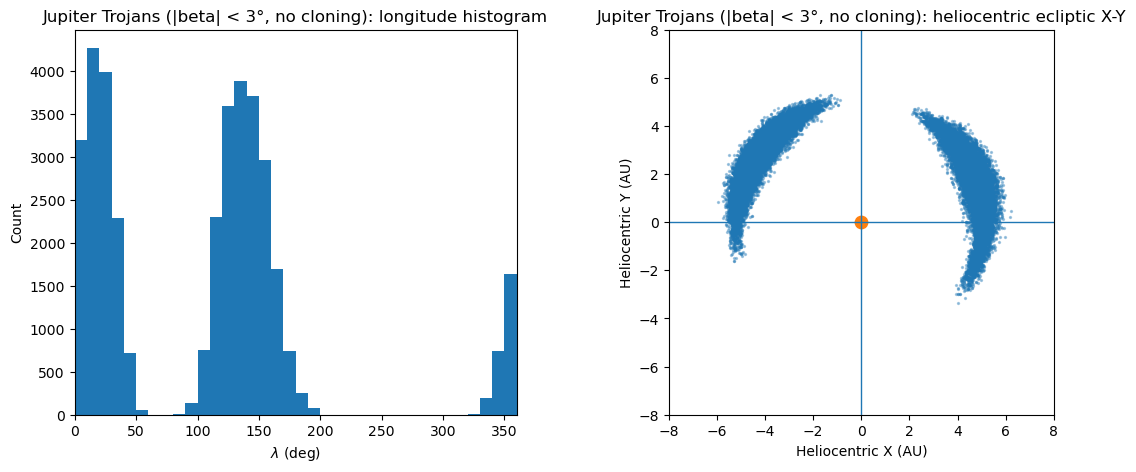

In [104]:
plot_population_lambda_hist_and_heliocentric_xy(
    population_data_xy=ecliptic_population_data_xy,
    population="Trojans",
    label="Jupiter Trojans (|beta| < 3°, no cloning)",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=702,
    xy_in_km=True,
)

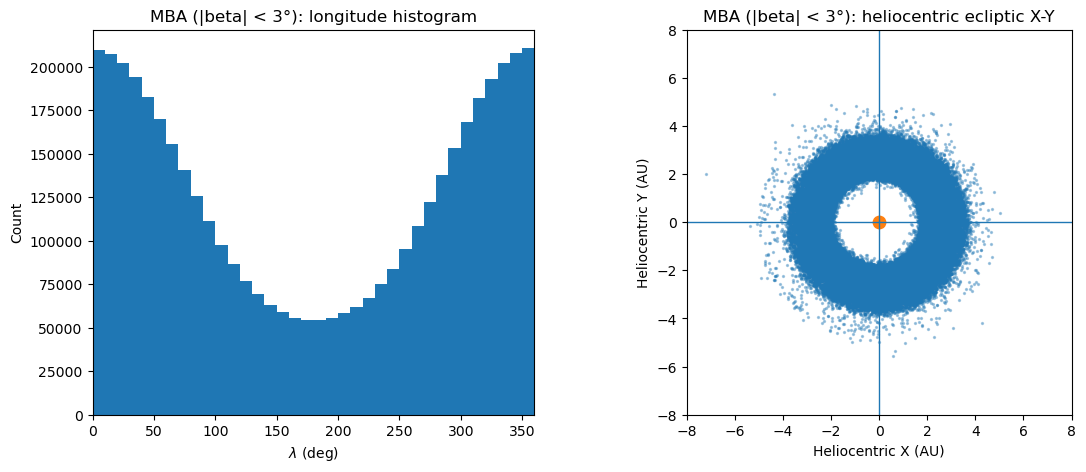

In [105]:
plot_population_lambda_hist_and_heliocentric_xy(
    population_data_xy=ecliptic_population_data_xy,
    population="MBA",
    label="MBA (|beta| < 3°)",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=721,
    xy_in_km=True,
)

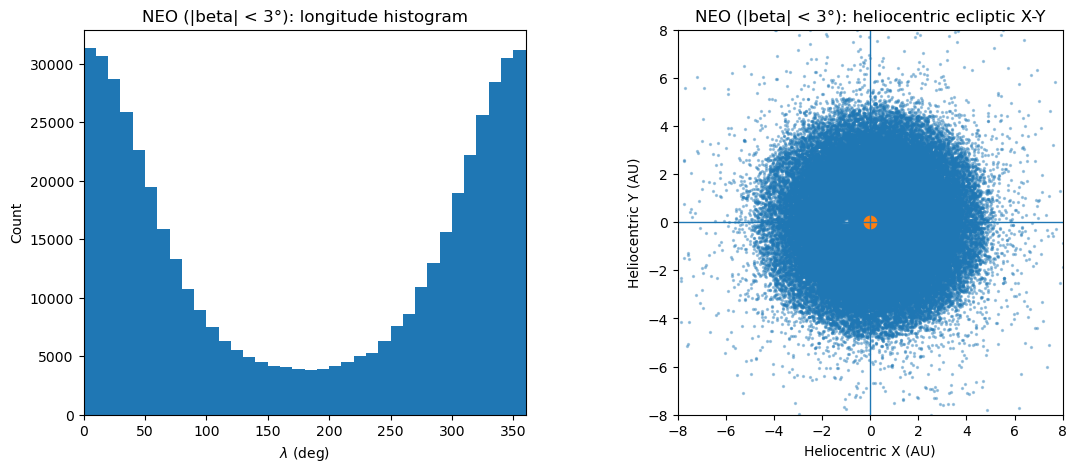

In [106]:
plot_population_lambda_hist_and_heliocentric_xy(
    population_data_xy=ecliptic_population_data_xy,
    population="NEO",
    label="NEO (|beta| < 3°)",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=722,
    xy_in_km=True,
)

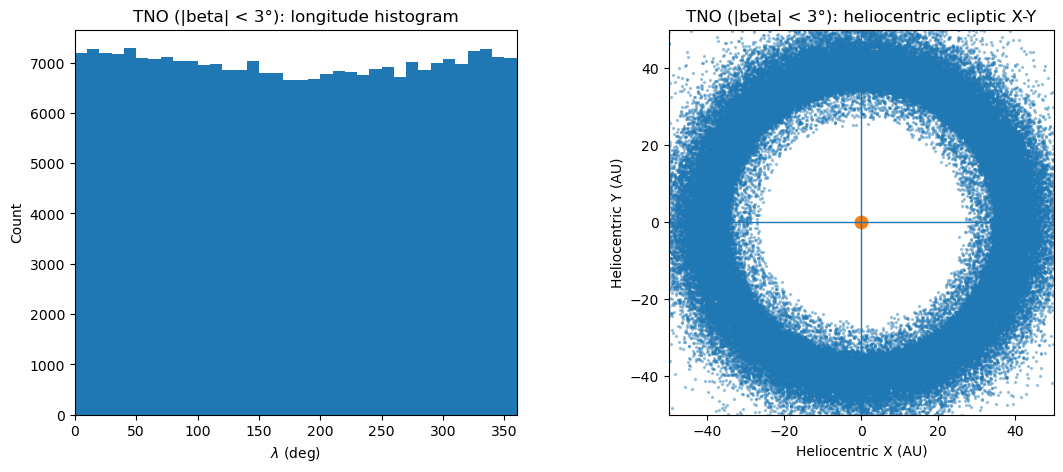

In [109]:
plot_population_lambda_hist_and_heliocentric_xy(
    population_data_xy=ecliptic_population_data_xy,
    population="TNO",
    label="TNO (|beta| < 3°)",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=50.0,
    max_xy_points=100_000,
    seed=722,
    xy_in_km=True,
)

In [29]:
def plot_eclipticstrip_single_population(
    data,
    label="Trojans",
    beta_max_deg=3.0,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points=150_000,
    seed=123,
    title="Ecliptic-strip plot",
):
    rng = np.random.default_rng(seed)

    lam   = np.mod(data["lam_deg"], 360.0)
    beta  = data["beta_deg"]
    vlam  = data["vlam"]
    vbeta = data["vbeta"]

    lam_lo, lam_hi = lam_window
    if lam_lo <= lam_hi:
        m = (lam >= lam_lo) & (lam <= lam_hi)
    else:
        m = (lam >= lam_lo) | (lam <= lam_hi)

    lam   = lam[m]
    beta  = beta[m]
    vlam  = vlam[m]
    vbeta = vbeta[m]

    print(f"{label} in window:", len(lam))

    if len(lam) > max_points:
        idx = rng.choice(len(lam), size=max_points, replace=False)
        lam   = lam[idx]
        beta  = beta[idx]
        vlam  = vlam[idx]
        vbeta = vbeta[idx]

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(9, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    # beta vs lambda
    ax1.scatter(lam, beta, s=1, alpha=0.22, label=label)
    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    # v_lambda vs lambda
    ax2.scatter(lam, vlam, s=1, alpha=0.22)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*vlam_ylim)

    # v_beta vs lambda
    ax3.scatter(lam, vbeta, s=1, alpha=0.22)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*vbeta_ylim)

    ax3.set_xlim(360, 0)

    fig.suptitle(title + f"\n{label} only, with |beta| < {beta_max_deg}°")
    plt.show()

Jupiter Trojans in window: 38147


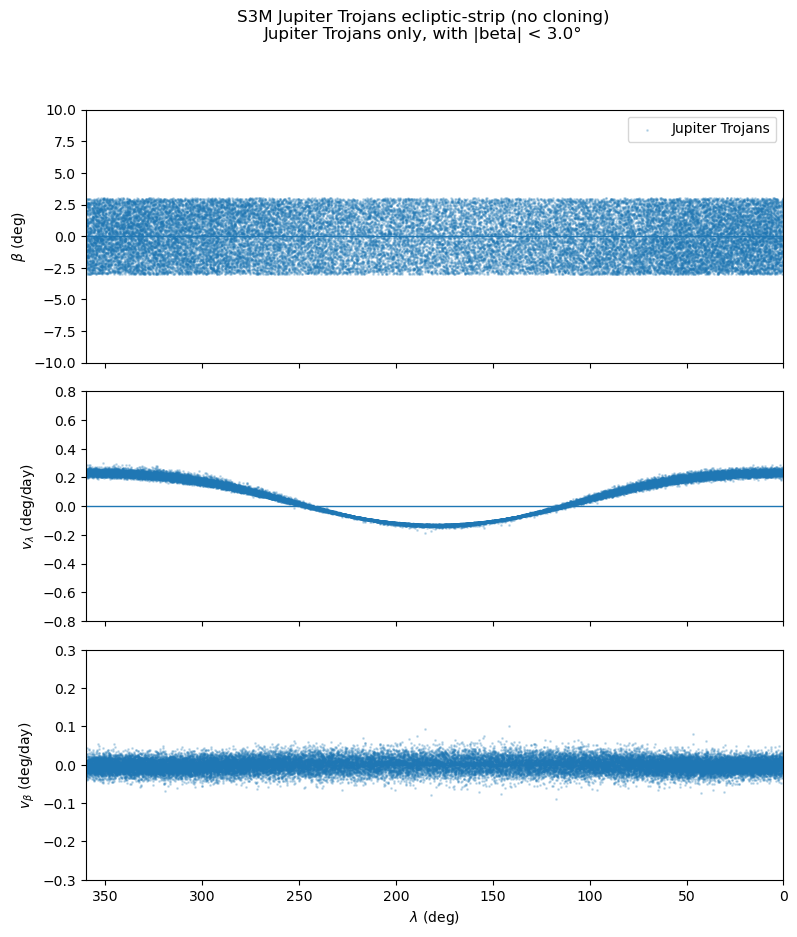

In [30]:
plot_eclipticstrip_single_population(
    data=fig5_trojan_ecliptic_noclone,
    label="Jupiter Trojans",
    beta_max_deg=3.0,
    lam_window=(0.0, 360.0),
    beta_ylim=(-10, 10),
    vlam_ylim=(-0.8, 0.8),
    vbeta_ylim=(-0.3, 0.3),
    max_points=150_000,
    seed=602,
    title="S3M Jupiter Trojans ecliptic-strip (no cloning)",
)

In [31]:
def make_mba_neo_ecliptic_plots_for_date(
    obstime_str,
    beta_max_deg=3.0,
    mba_clone_factor=None,
    neo_clone_factor=None,
    object_chunk=20_000,
    rate_chunk=50_000,
    verbose=True,
):
    if mba_clone_factor is None:
        mba_clone_factor = clone_sources["MBA"]["clone_factor"]
    if neo_clone_factor is None:
        neo_clone_factor = clone_sources["NEO"]["clone_factor"]

    print(f"\n=== Building MBA + NEO ecliptic-strip plots for {obstime_str} ===")

    mba_data = build_eclipticstrip_for_population_chunked(
        df=clone_sources["MBA"]["df"],
        scorer=clone_sources["MBA"]["scorer"],
        clone_factor=mba_clone_factor,
        obstime_str=obstime_str,
        beta_max_deg=beta_max_deg,
        object_chunk=object_chunk,
        rate_chunk=rate_chunk,
        rng=np.random.default_rng(501),
        verbose=verbose,
    )

    neo_data = build_eclipticstrip_for_population_chunked(
        df=clone_sources["NEO"]["df"],
        scorer=clone_sources["NEO"]["scorer"],
        clone_factor=neo_clone_factor,
        obstime_str=obstime_str,
        beta_max_deg=beta_max_deg,
        object_chunk=object_chunk,
        rate_chunk=rate_chunk,
        rng=np.random.default_rng(502),
        verbose=verbose,
    )

    plot_eclipticstrip_overlay(
        mba_data=mba_data,
        neo_data=neo_data,
        beta_max_deg=beta_max_deg,
        lam_window=(0.0, 360.0),
        beta_ylim=(-10, 10),
        vlam_ylim=(-0.8, 0.8),
        vbeta_ylim=(-0.3, 0.3),
        max_points_mba=150_000,
        max_points_neo=50_000,
        seed=503,
        title=f"S3M MBA + NEO ecliptic-strip ({obstime_str})",
    )

    return mba_data, neo_data

In [33]:
def make_trojan_ecliptic_plot_for_date(
    obstime_str,
    beta_max_deg=3.0,
    trojan_clone_factor=None,
    object_chunk=20_000,
    rate_chunk=50_000,
    verbose=True,
):
    if trojan_clone_factor is None:
        trojan_clone_factor = clone_sources["Trojans"]["clone_factor"]

    print(f"\n=== Building Trojan ecliptic-strip plot for {obstime_str} ===")

    trojan_data = build_eclipticstrip_for_population_chunked(
        df=clone_sources["Trojans"]["df"],
        scorer=clone_sources["Trojans"]["scorer"],
        clone_factor=trojan_clone_factor,
        obstime_str=obstime_str,
        beta_max_deg=beta_max_deg,
        object_chunk=object_chunk,
        rate_chunk=rate_chunk,
        rng=np.random.default_rng(621),
        verbose=verbose,
    )

    plot_eclipticstrip_single_population(
        data=trojan_data,
        label="Trojans",
        beta_max_deg=beta_max_deg,
        lam_window=(0.0, 360.0),
        beta_ylim=(-10, 10),
        vlam_ylim=(-0.8, 0.8),
        vbeta_ylim=(-0.3, 0.3),
        max_points=150_000,
        seed=622,
        title=f"S3M Trojans ecliptic-strip ({obstime_str})",
    )

    return trojan_data


=== Building MBA + NEO ecliptic-strip plots for 2025-03-21T00:00:00 ===
Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,36

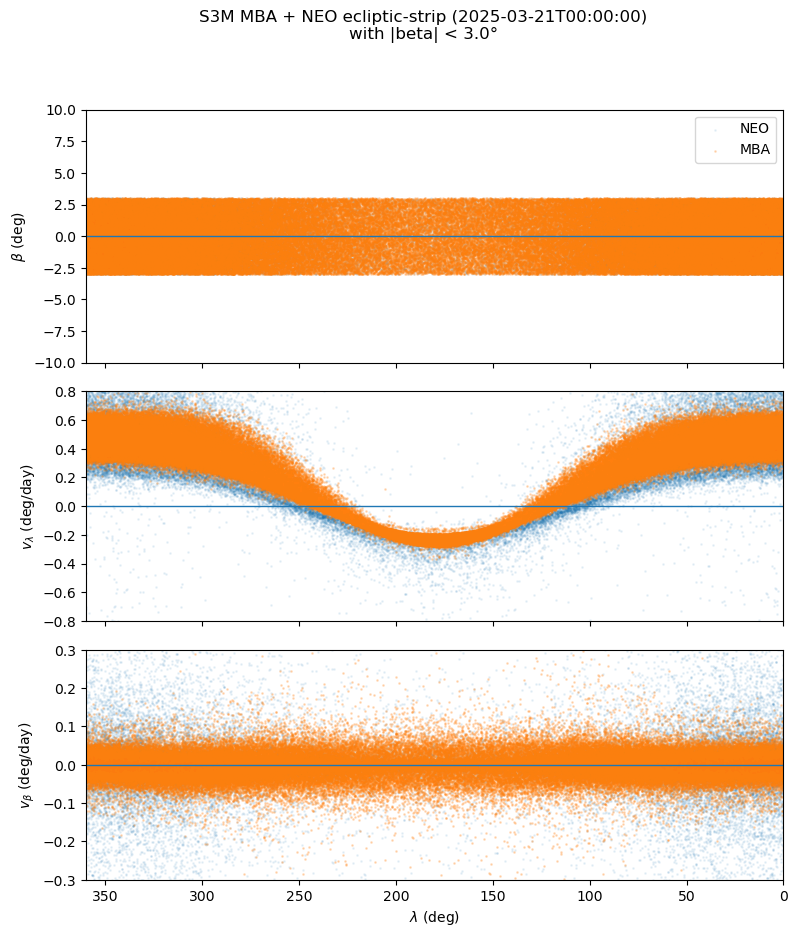

In [32]:
mba_mar21, neo_mar21 = make_mba_neo_ecliptic_plots_for_date(
    "2025-03-21T00:00:00"
)


=== Building Trojan ecliptic-strip plot for 2025-03-21T00:00:00 ===
Objects 0 to 20,000 of 179,882
Objects 20,000 to 40,000 of 179,882
Objects 40,000 to 60,000 of 179,882
Objects 60,000 to 80,000 of 179,882
Objects 80,000 to 100,000 of 179,882
Objects 100,000 to 120,000 of 179,882
Objects 120,000 to 140,000 of 179,882
Objects 140,000 to 160,000 of 179,882
Objects 160,000 to 179,882 of 179,882
Trojans in window: 379372


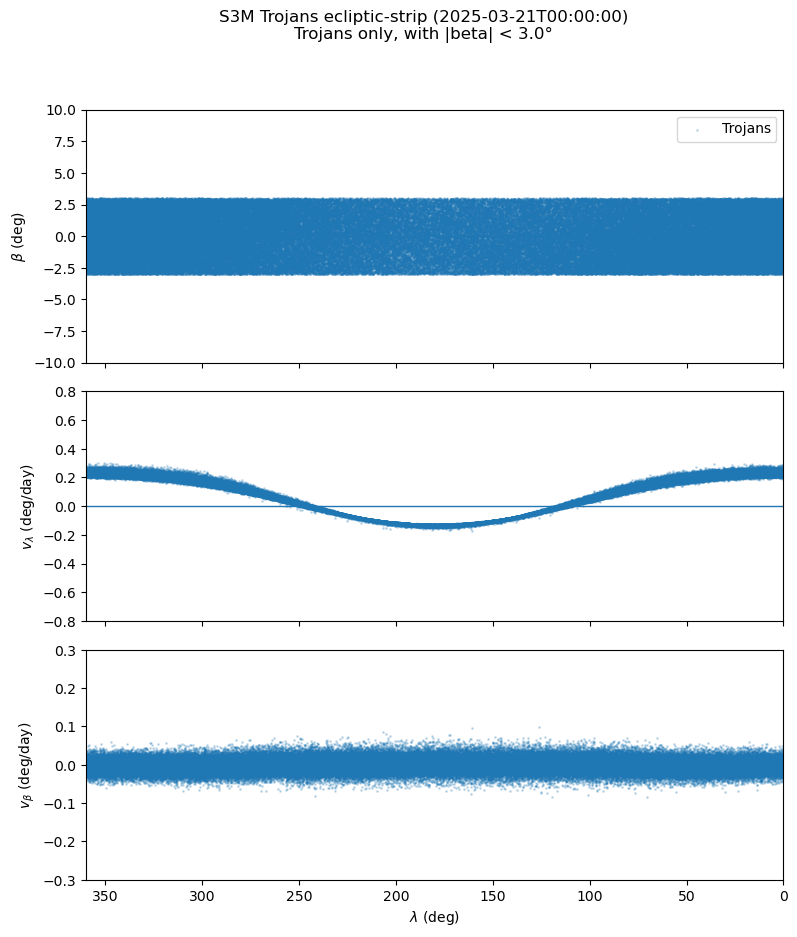

In [34]:
trojan_sep21 = make_trojan_ecliptic_plot_for_date(
    "2025-03-21T00:00:00"
)

In [35]:
def elements_to_eclipticstrip_quantities_with_xy_chunk(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    beta_max_deg=3.0,
    rate_chunk=100_000,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import SkyCoord, GCRS, GeocentricTrueEcliptic

    t_obs = Time(obstime_str, scale="tdb")

    # 1) heliocentric ecliptic state from orbital elements
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=rate_chunk,
        show_progress=False,
    )

    # Keep heliocentric ecliptic X,Y before any observer transform
    x_helio_ecl = r_obj_ecl[:, 0].astype(np.float32)
    y_helio_ecl = r_obj_ecl[:, 1].astype(np.float32)

    # 2) ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    del r_obj_ecl, v_obj_ecl

    # 3) observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # 4) topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    del r_obj_helio, v_obj_helio

    # 5) Cartesian -> RA, Dec and rates
    x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & np.isfinite(r2) &
        (rho2 > 0) & (r2 > 0)
    )

    ra_deg       = (np.rad2deg(ra[good]) % 360.0).astype(np.float32)
    dec_deg      = np.rad2deg(dec[good]).astype(np.float32)
    dra_deg_day  = (np.rad2deg(dra[good])  * 86400.0).astype(np.float32)
    ddec_deg_day = (np.rad2deg(ddec[good]) * 86400.0).astype(np.float32)

    x_helio_ecl = x_helio_ecl[good]
    y_helio_ecl = y_helio_ecl[good]

    del r_rel, v_rel, x, y, z, vx, vy, vz, rho2, r2, rho, ra, dec, dra, ddec, good

    # 6) convert to ecliptic sky coordinates
    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )
    ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg  = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    # 7) convert RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam  = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    lam_deg     = lam_deg[finite]
    beta_deg    = beta_deg[finite]
    vlam        = vlam[finite]
    vbeta       = vbeta[finite]
    x_helio_ecl = x_helio_ecl[finite]
    y_helio_ecl = y_helio_ecl[finite]

    # 8) ecliptic-strip cut
    m_beta = np.abs(beta_deg) < beta_max_deg

    return (
        lam_deg[m_beta],
        beta_deg[m_beta],
        vlam[m_beta],
        vbeta[m_beta],
        x_helio_ecl[m_beta],
        y_helio_ecl[m_beta],
    )

In [36]:
def build_eclipticstrip_for_population_with_xy_chunked(
    df,
    scorer,
    clone_factor,
    obstime_str,
    beta_max_deg=3.0,
    object_chunk=50_000,
    rate_chunk=100_000,
    rng=None,
    verbose=True,
):
    import gc
    from astropy.time import Time

    if rng is None:
        rng = np.random.default_rng(42)

    n_obj = len(df)

    lam_list = []
    beta_list = []
    vlam_list = []
    vbeta_list = []
    xh_list = []
    yh_list = []

    a_all     = df["q"].to_numpy(dtype=np.float32) / (1.0 - df["e"].to_numpy(dtype=np.float32))
    e_all     = df["e"].to_numpy(dtype=np.float32)
    inc_all   = df["i"].to_numpy(dtype=np.float32)
    raan_all  = df["node"].to_numpy(dtype=np.float32)
    argp_all  = df["argperi"].to_numpy(dtype=np.float32)
    tp_all    = df["t_p"].to_numpy(dtype=np.float64)

    t_obs = Time(obstime_str, scale="tdb")
    AU_km_val = 149597870.7
    mu_sun_km3_s2 = 1.32712440018e11

    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0 + object_chunk, n_obj)

        if verbose:
            print(f"Objects {i0:,} to {i1:,} of {n_obj:,}")

        a_chunk    = a_all[i0:i1]
        e_chunk    = e_all[i0:i1]
        inc_chunk  = inc_all[i0:i1]
        raan_chunk = raan_all[i0:i1]
        argp_chunk = argp_all[i0:i1]
        tp_chunk   = tp_all[i0:i1]

        # clone this chunk only
        a_rep    = np.repeat(a_chunk, clone_factor)
        e_rep    = np.repeat(e_chunk, clone_factor)
        inc_rep  = np.repeat(inc_chunk, clone_factor)
        raan_rep = np.repeat(raan_chunk, clone_factor)
        argp_rep = np.repeat(argp_chunk, clone_factor)

        # randomize mean anomaly by shifting perihelion time
        a_km = a_rep.astype(np.float64) * AU_km_val
        n_rad_s = np.sqrt(mu_sun_km3_s2 / (a_km**3))
        M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep))
        dt_s = M_rand / n_rad_s
        tp_new = t_obs.mjd - (dt_s / 86400.0)

        lam_deg, beta_deg, vlam, vbeta, xh, yh = elements_to_eclipticstrip_quantities_with_xy_chunk(
            a_AU=a_rep,
            e=e_rep,
            inc=inc_rep,
            raan=raan_rep,
            argp=argp_rep,
            tp_mjd=tp_new,
            obstime_str=obstime_str,
            scorer=scorer,
            beta_max_deg=beta_max_deg,
            rate_chunk=rate_chunk,
        )

        lam_list.append(lam_deg)
        beta_list.append(beta_deg)
        vlam_list.append(vlam)
        vbeta_list.append(vbeta)
        xh_list.append(xh)
        yh_list.append(yh)

        del a_chunk, e_chunk, inc_chunk, raan_chunk, argp_chunk, tp_chunk
        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        del lam_deg, beta_deg, vlam, vbeta, xh, yh
        gc.collect()

    return {
        "lam_deg": np.concatenate(lam_list).astype(np.float32) if lam_list else np.array([], dtype=np.float32),
        "beta_deg": np.concatenate(beta_list).astype(np.float32) if beta_list else np.array([], dtype=np.float32),
        "vlam": np.concatenate(vlam_list).astype(np.float32) if vlam_list else np.array([], dtype=np.float32),
        "vbeta": np.concatenate(vbeta_list).astype(np.float32) if vbeta_list else np.array([], dtype=np.float32),
        "x_helio_ecl": np.concatenate(xh_list).astype(np.float32) if xh_list else np.array([], dtype=np.float32),
        "y_helio_ecl": np.concatenate(yh_list).astype(np.float32) if yh_list else np.array([], dtype=np.float32),
    }

In [51]:
fig5_trojan_ecliptic_noclone_xy = build_eclipticstrip_for_population_with_xy_chunked(
    df=clone_sources["Trojans"]["df"],
    scorer=clone_sources["Trojans"]["scorer"],
    clone_factor=1,          # NO cloning
    obstime_str=obstime_str,
    beta_max_deg=3.0,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(701),
    verbose=True,
)

Objects 0 to 20,000 of 179,882
Objects 20,000 to 40,000 of 179,882
Objects 40,000 to 60,000 of 179,882
Objects 60,000 to 80,000 of 179,882
Objects 80,000 to 100,000 of 179,882
Objects 100,000 to 120,000 of 179,882
Objects 120,000 to 140,000 of 179,882
Objects 140,000 to 160,000 of 179,882
Objects 160,000 to 179,882 of 179,882


In [52]:
def plot_lambda_hist_and_heliocentric_xy(
    data,
    label="Jupiter Trojans",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=123,
    xy_in_km=True,   # set True if stored x,y are in km
):
    rng = np.random.default_rng(seed)

    lam = np.mod(data["lam_deg"], 360.0)
    xh  = data["x_helio_ecl"].copy()
    yh  = data["y_helio_ecl"].copy()

    # convert km -> AU if needed
    if xy_in_km:
        AU_km = 149597870.7
        xh = xh / AU_km
        yh = yh / AU_km

    # sample XY points if needed
    if len(xh) > max_xy_points:
        idx = rng.choice(len(xh), size=max_xy_points, replace=False)
        xh_plot = xh[idx]
        yh_plot = yh[idx]
    else:
        xh_plot = xh
        yh_plot = yh

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(13, 5),
        gridspec_kw=dict(wspace=0.28)
    )

    # lambda histogram
    ax1.hist(lam, bins=lam_bins)
    ax1.set_xlabel(r"$\lambda$ (deg)")
    ax1.set_ylabel("Count")
    ax1.set_title(f"{label}: longitude histogram")
    ax1.set_xlim(0, 360)

    # heliocentric XY plane
    ax2.scatter(xh_plot, yh_plot, s=2, alpha=0.35)
    ax2.scatter([0], [0], s=80, marker="o")  # Sun
    ax2.axhline(0, lw=1)
    ax2.axvline(0, lw=1)
    ax2.set_xlabel("Heliocentric X (AU)")
    ax2.set_ylabel("Heliocentric Y (AU)")
    ax2.set_title(f"{label}: heliocentric ecliptic X-Y")
    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlim(-xy_max_au, xy_max_au)
    ax2.set_ylim(-xy_max_au, xy_max_au)

    plt.show()

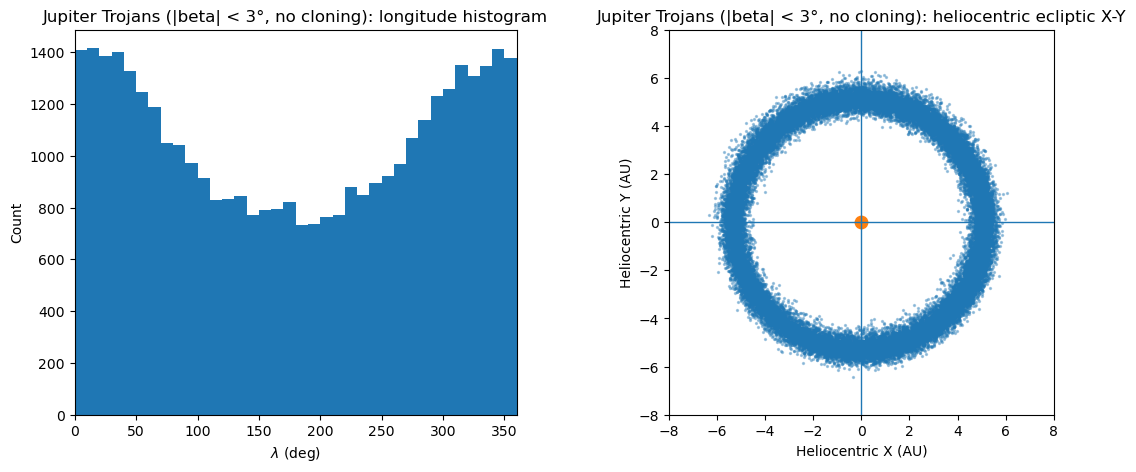

In [53]:
plot_lambda_hist_and_heliocentric_xy(
    data=fig5_trojan_ecliptic_noclone_xy,
    label="Jupiter Trojans (|beta| < 3°, no cloning)",
    lam_bins=np.arange(0, 361, 10),
    xy_max_au=8.0,
    max_xy_points=100_000,
    seed=702,
    xy_in_km=True,
)